Name : Mohammad Ayaan Khan

USC ID : 4147952900

Email : mkhan736@usc.edu

# DSCI 552 — Homework 2
**Combined Cycle Power Plant regression + ISLR 2.4.1 and 2.4.7**

Predictors: AT (temperature T), V (exhaust vacuum), AP (ambient pressure), RH (relative humidity).
Response: PE (net hourly electrical energy output, EP). Working with Sheet 1.

### Setup

In [3]:
import io, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
%matplotlib inline

pred=["AT", "V", "AP", "RH"]
resp="PE"

## 1(a) Download the data

In [5]:
data = "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip"
raw = urllib.request.urlopen(data).read()
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    with z.open("CCPP/Folds5x2_pp.xlsx") as f:
        df = pd.read_excel(f, sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b) Exploring the data\n\n
### 1(b)i — Rows, columns, and what they represent

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", list(df.columns))
print("Missing values:", int(df.isna().sum().sum()))

Rows: 9568
Columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']
Missing values: 0


**Answer.** The dataset contains a total of **9568 rows** and **5 columns**. Every **row** indicates an hourly average record received from the factory while in full operation from 2006 to 2011. The first four **columns** contain the parameters determining the environment which are AT (temperature), V (exhaust vacuum), AP (ambient pressure) and RH (relative humidity), while the last column, PE, presents the output - the net energy produced per hour. In addition, there are no missing information points in the dataset.

### 1(b)ii — Pairwise scatterplots

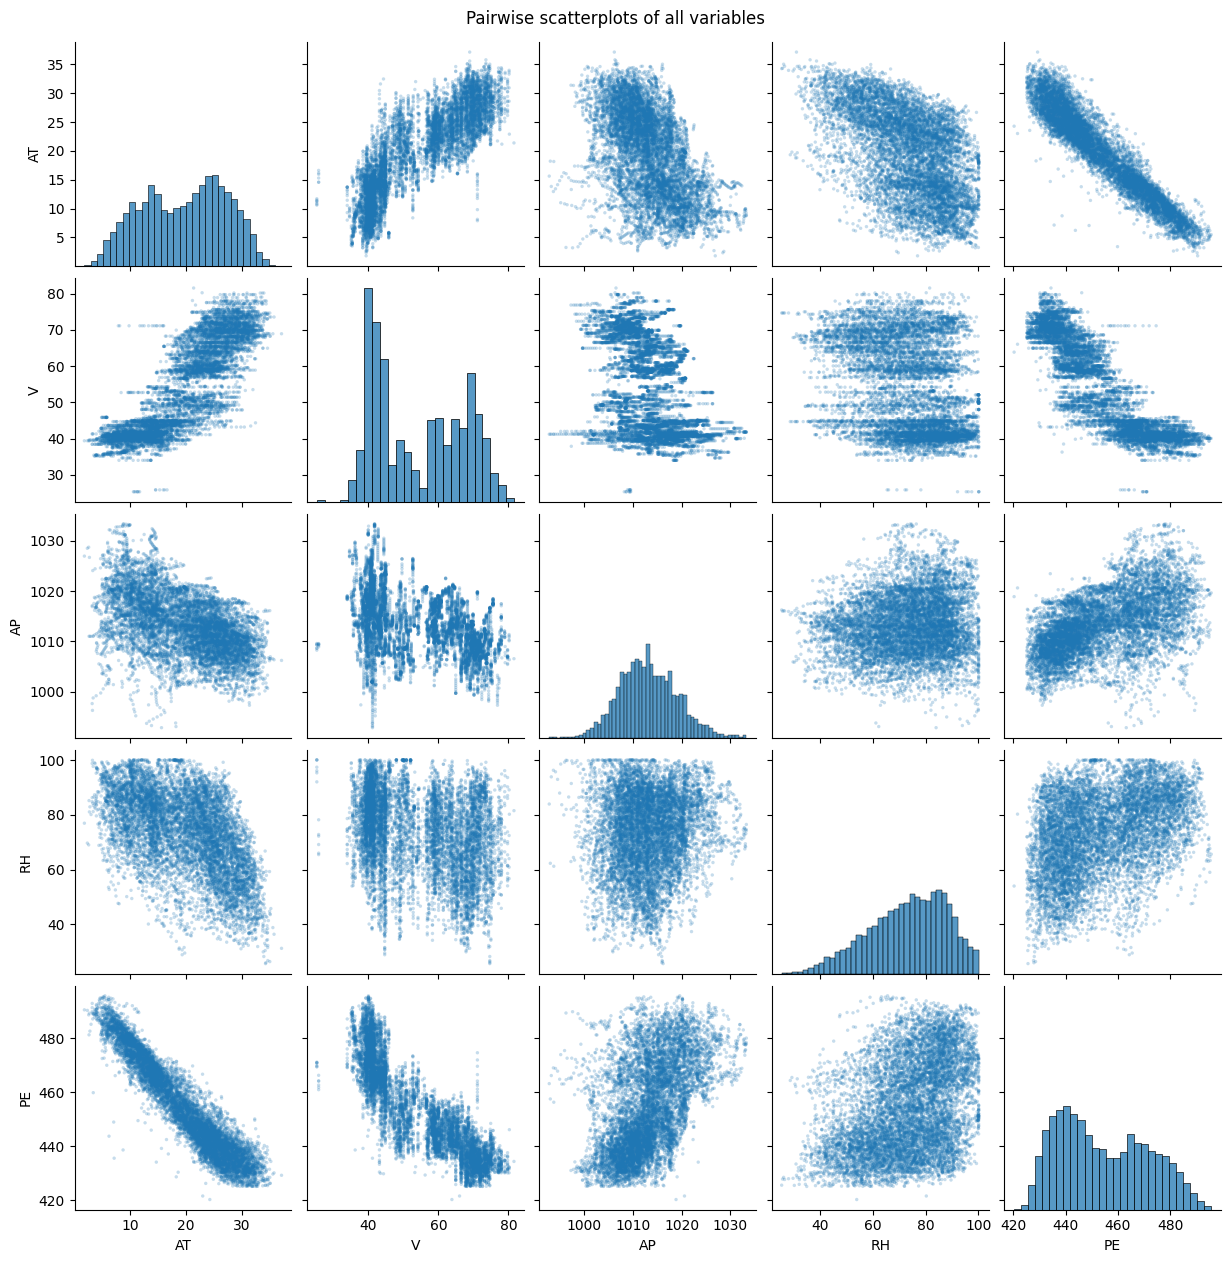

In [9]:
#All variables scatterplot matrix is made to check pairwise relations; small, semi-translucent points minimize overplotting and histograms are on the diagonal to see the distribution of variables
sns.pairplot(df, plot_kws=dict(s=6, alpha=0.25, edgecolor="none"), diag_kind="hist")
plt.suptitle("Pairwise scatterplots of all variables", y=1.01)
plt.show()

**Findings.** Here, AT's relationship with PE is characterized by very clear negative linear correlation, with higher amounts of AT being associated with lower amounts of PE. Similarly, V shows a negative correlation with PE. AT and V have a positive correlation with each other. There is moderate positive correlation between AP and PE, while RH and PE exhibit weak positive correlation. With regard to the graphs of AT and PE and V and PE, it can be seen that there is a linear plot with slight curve, indicating mild nonlinear nature of the relationship a bit further.

### 1(b)iii — Summary statistics

In [10]:
# mean, median, range, quartiles, and IQR for every variable
rows = []
for c in df.columns:
    s = df[c]
    rows.append([c, s.mean(), s.median(), s.min(), s.max(), s.max() - s.min(),
                 s.quantile(0.25), s.quantile(0.75), s.quantile(0.75) - s.quantile(0.25)])
summ = pd.DataFrame(rows, columns=["variable","mean","median","min","max","range","Q1","Q3","IQR"]).round(3)
summ

,variable,mean,median,min,max,range,Q1,Q3,IQR
0,AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
1,V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
2,AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
3,RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
4,PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


## 1(c) Simple linear regression, one predictor at a time
For each predictor we fit `PE ~ predictor`, note the slope, its p-value, and R², then plot the fit.

In [12]:
# A simple regression model of the response is fitted for every predictor and slopes are kept for later comparison with multiple regression coefficients
simple_coef = {}
print(f"{"pred":<5}{"slope":>12}{"p-value":>14}{"R^2":>10}")
for p in pred:
    X = sm.add_constant(df[p])
    model = sm.OLS(df[resp], X).fit()
    simple_coef[p] = model.params[p]
    print(f"{p:<5}{model.params[p]:>12.4f}{model.pvalues[p]:>14.2e}{model.rsquared:>10.4f}")

pred        slope       p-value       R^2
AT        -2.1713      0.00e+00    0.8989
V         -1.1681      0.00e+00    0.7565
AP         1.4899      0.00e+00    0.2688
RH         0.4557      0.00e+00    0.1519


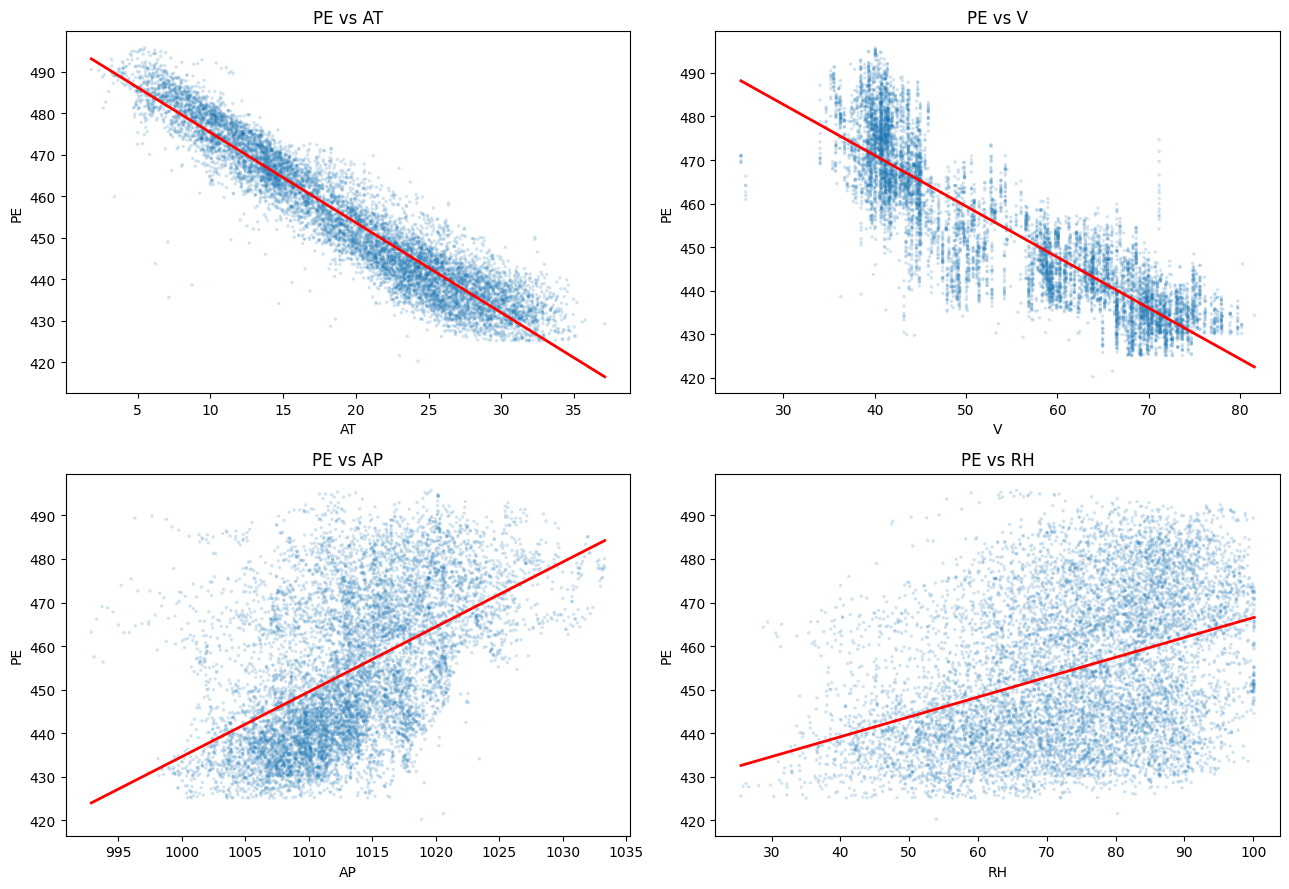

In [13]:
# Each predictor is plotted on a 2x2 grid against the response with the fitted regression line superimposing the graph in red
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for idx, p in enumerate(pred):
    a = ax[idx // 2, idx % 2]
    a.scatter(df[p], df[resp], s=6, alpha=0.2, edgecolor="none")
    xs = np.linspace(df[p].min(), df[p].max(), 100)
    fit = sm.OLS(df[resp], sm.add_constant(df[p])).fit()
    a.plot(xs, fit.params["const"] + fit.params[p] * xs, "r-", lw=2)
    a.set_xlabel(p); a.set_ylabel(resp); a.set_title(f"PE vs {p}")
plt.tight_layout(); plt.show()

**Results.** All of the predictors have a very low value of p (close to 0), meaning that when looked at alone they can be said to causally affect PE with statistically significance. The strengths of the predictors differ a lot, however: AT explains R² = 0.90 (slope ≈ −2.17), V explains R² = 0.76 (slope−1.17), AP accounts for the variance to the level of R² = 0.27 (slope ≈ +1.49), RH has only R² = 0.15 (slope ≈ +0.46). Thus, AT and V are the main predictors.

**Outliers.** The scatterplots show only a few points rising far above the general grouping and the student residuals indicate having also very few points exceeding the threshold of ±3. Being of n = 9568, these few points do not have much impact on the resulting regression functions, hence omitting the points wouldn’t be mandatory and it wouldn’t change the results.

## 1(d) Multiple regression with all predictors

In [16]:
# A multiple regression of a response on all predictors is fitted and coefficients are stored for use in calculation in (e) and let’s print the whole summary
Xm = sm.add_constant(df[pred])
multiple = sm.OLS(df[resp], Xm).fit()
multiple_coef = {p: multi.params[p] for p in pred}   # save for part (e)
print(multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:33:50   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

**Results.** The complete model fits nicely (R² = 0.929). If we look at the p-values, it should be noticed that **the coefficient of each predictor is significant at any known level, so we have to reject H₀: βⱼ = 0 for all the predictors (AT, V, AP, RH)**. It should be emphasized that AP is the least significant predictor (p ≈ 5e-11).
It is important to note that the coefficients differ from those of the simple fits: AT remains large and negative (approximately −1.98) while V drops from −1.17 to −0.23 and AP decreases from +1.49 to +0.06. Also, RH **changes sign** shifting from +0.46 to −0.16.

## 1(e) Simple vs. multiple regression coefficients

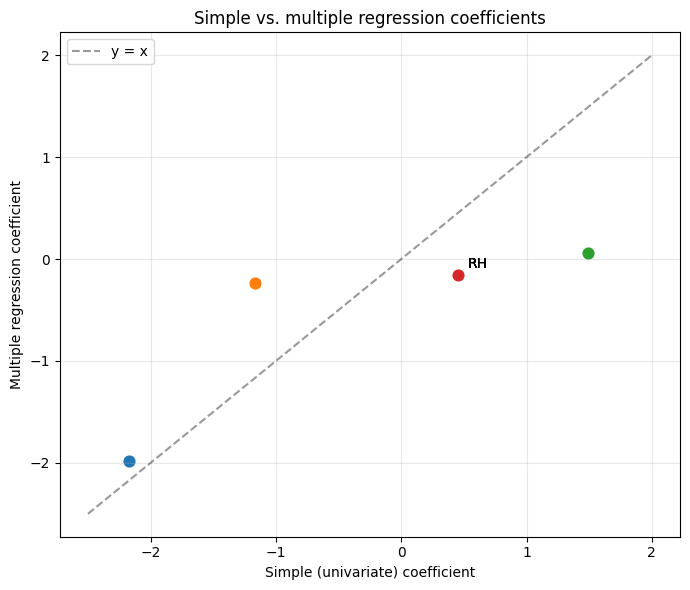

In [17]:
# A simple regression coefficient of a predictor is plotted against its coefficient found in multiple regression; any points that are not close to the dashed line y = x represent changes in the effect after correction for other predictors
plt.figure(figsize=(7, 6))
for x in pred:
    plt.scatter(simple_coef[x], multiple_coef[x], s=60)
    plt.annotate(p, (simple_coef[p], multiple_coef[p]),
                 textcoords="offset points", xytext=(7, 5))
lims = [-2.5, 2.0]
plt.plot(lims, lims, "k--", alpha=0.4, label="y = x")
plt.xlabel("Simple (univariate) coefficient")
plt.ylabel("Multiple regression coefficient")
plt.title("Simple vs. multiple regression coefficients")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Comparison.** The points are not located on the line y = x, and now the simple and multiple regression coefficients diverge. AT is the nearest point to the line because it dominates the outcome and is barely affected. V and AP regress toward zero, while RH changes from being positive to negative with the addition of other predictors. This is true because predictors are correlated (particularly AT and V): in the case of simple regression, each predictor receives credit for its shared contribution, whereas in multiple regression this contribution is evaluated assuming that the other predictors are fixed.

## 1(f) Nonlinear association (cubic fits)
For each predictor we fit `PE ~ X + X² + X³`. The predictors are standardized first so that X², X³
don't create a numerically ill-conditioned (rank-deficient) design matrix — AP values near 1013 give
cubes around 1e9 otherwise.

In [20]:
# Different predictors are tested in a cubic polynomial regression against standardized values and p-values of linear parts of regression model are printed to check whether there is non-linearity
t = pd.DataFrame(StandardScaler().fit_transform(df[pred]), columns=pred)
print(f"{"pred":<5}{"p(X)":>12}{"p(X^2)":>12}{"p(X^3)":>12}")
for p in pred:
    Xp = sm.add_constant(pd.DataFrame({p: t[p], p+"2": t[p]**2, p+"3": t[p]**3}))
    m = sm.OLS(df[resp].values, Xp).fit()
    print(f"{p:<5}{m.pvalues[p]:>12.2e}{m.pvalues[p+"2"]:>12.2e}{m.pvalues[p+"3"]:>12.2e}")

pred         p(X)      p(X^2)      p(X^3)
AT       0.00e+00   3.31e-231   3.65e-110
V        0.00e+00   8.98e-131    1.37e-02
AP       0.00e+00    2.19e-46    2.12e-67
RH      9.65e-152    1.01e-01    1.44e-05


**Evidence of nonlinearity.** Certainly. The data reveal substantial significance of both quadratic and cubic variables in case of **AT, V, and AP**, indicating a clear non-linear relationship. The cubic variable for **RH** shows significance and has a p value around 1e-5 while the quadratic one has a borderline value of p around 0.10, which indicates a rather weaker, but still existent non linearity. In general, it can be stated that all predictors deviate from linear dependence of PE, with **AT, V, and AP** being the most strongly affected.

## 1(g) Pairwise interaction terms

In [23]:
# An interaction regression is fitted with main effects and all interactions being taken into account and the coefficients and p-values of interaction terms are reported
Xg = t.copy()
for i in range(len(pred)):
    for j in range(i + 1, len(pred)):
        Xg[pred[i] + ":" + pred[j]] = t[pred[i]] * t[pred[j]]
inter_model = sm.OLS(df[resp].values, sm.add_constant(Xg)).fit()
for c in [c for c in Xg.columns if ":" in c]:
    f= "significant" if inter_model.pvalues[c] < 0.05 else "not significant"
    print(f"{c:<8} coef={inter_model.params[c]:>8.4f}  p={inter_model.pvalues[c]:.2e}  ({f})")

AT:V     coef=  1.9858  p=3.33e-117  (significant)
AT:AP    coef=  0.0778  p=4.52e-01  (not significant)
AT:RH    coef= -0.5690  p=1.22e-10  (significant)
V:AP     coef=  0.5141  p=2.88e-07  (significant)
V:RH     coef=  0.1556  p=8.62e-02  (not significant)
AP:RH    coef= -0.1397  p=3.36e-02  (significant)


**Results.** Based on the findings, it can be noted that out of total six interactions, four are statistically significant at 0.05 level, namely, **AT:V, AT:RH, V:AP, and AP:RH**, whereas two interactions, AT:AP and V:RH are found to lack significance. Therefore, it can be concluded that there are predictive interactions which take place between the variables when predicting the PE, in which case the most substantial interaction occurs between the AT and V.

## 1(h) Improved model on a 70/30 split
Model 1 is plain linear regression on all predictors. Model 2 starts from all quadratic terms and all
pairwise interactions, then keeps only the terms significant at p < 0.05 on the **training** data. Both
are evaluated on the held-out 30%.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(df[pred], df[resp],
                                                    test_size=0.30, random_state=42)

# Model 1: linear regression on the four raw predictors
lr = LinearRegression().fit(X_train, y_train)
m1_train = mean_squared_error(y_train, lr.predict(X_train))
m1_test  = mean_squared_error(y_test,  lr.predict(X_test))
print(f"Model 1 (all predictors):  train MSE = {m1_train:.4f}   test MSE = {m1_test:.4f}")

Model 1 (all predictors):  train MSE = 20.5808   test MSE = 21.2399


In [25]:
# Model 2: standardize on train, build quadratics + interactions, prune by train p-values
scaler = StandardScaler().fit(X_train)
z_train = pd.DataFrame(scaler.transform(X_train), columns=pred, index=X_train.index)
z_test  = pd.DataFrame(scaler.transform(X_test),  columns=pred, index=X_test.index)

# Design a matrix that incorporates the main effects, square appearing multiplication factors, and multiplication phase forms, run a regression modelling on a set such that only significant variables that meet the threshold of 0.05 are retained for further analysis.
def build_design(zf):
    d = zf.copy()
    for p in pred:                       # quadratic terms
        d[p + "^2"] = zf[p] ** 2
    for i in range(len(pred)):           # pairwise interactions
        for j in range(i + 1, len(pred)):
            d[pred[i] + ":" + pred[j]] = zf[pred[i]] * zf[pred[j]]
    return d

D_train, D_test = build_design(z_train), build_design(z_test)
full = sm.OLS(y_train.values, sm.add_constant(D_train)).fit()
keep = [c for c in D_train.columns if full.pvalues[c] < 0.05]   # significant terms only
print("Kept terms:", keep)

reduced = sm.OLS(y_train.values, sm.add_constant(D_train[keep])).fit()
m2_train = mean_squared_error(y_train, reduced.predict(sm.add_constant(D_train[keep])))
m2_test  = mean_squared_error(y_test,  reduced.predict(sm.add_constant(D_test[keep])))
print(f"Model 2 (pruned quad+interactions):  train MSE = {m2_train:.4f}   test MSE = {m2_test:.4f}")

Kept terms: ['AT', 'V', 'AP', 'RH', 'AT^2', 'AP^2', 'RH^2', 'AT:V', 'AT:RH', 'AP:RH']
Model 2 (pruned quad+interactions):  train MSE = 17.9178   test MSE = 18.6943


**Results.** Model 1 achieves a training MSE of roughly 20.6 and a testing MSE of around 21.2. In contrast, Model 2 which has been pruned to contain mainly significant interaction and quadratic terms has a training MSE of 17.9 and a testing MSE of 18.7.   
Adding meaningful non-linear and interaction structures seems to yield a positive outcome, and since the two performance metrics do not differ that significantly we can assume that there is no sign of overfitting.

## 1(i) KNN regression
KNN regression on raw and on normalized features, k from 1 to 100, using the same 70/30 split. Errors
are plotted against 1/k (so the flexible, small-k end is on the right).

In [26]:
# Apply KNN regression for k ranging from 1 to 100 on both unprocessed data and normalized data, collect training and testing MSE data for each value of k, and report the performance measure for the optimal value of k for both cases to illustrate the effect of feature normalization.
scaler_knn = StandardScaler().fit(X_train)
Xtr_n, Xte_n = scaler_knn.transform(X_train), scaler_knn.transform(X_test)

ks = list(range(1, 101))
results = {}
for label, (A, B) in {"Raw": (X_train.values, X_test.values),
                      "Normalized": (Xtr_n, Xte_n)}.items():
    tr_mse, te_mse = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(A, y_train)
        tr_mse.append(mean_squared_error(y_train, knn.predict(A)))
        te_mse.append(mean_squared_error(y_test,  knn.predict(B)))
    best_k = ks[int(np.argmin(te_mse))]
    results[label] = (tr_mse, te_mse, best_k)
    print(f"{label:<11} best k = {best_k:3d}   test MSE = {min(te_mse):.4f}")

Raw         best k =   5   test MSE = 15.7268
Normalized  best k =   4   test MSE = 14.3057


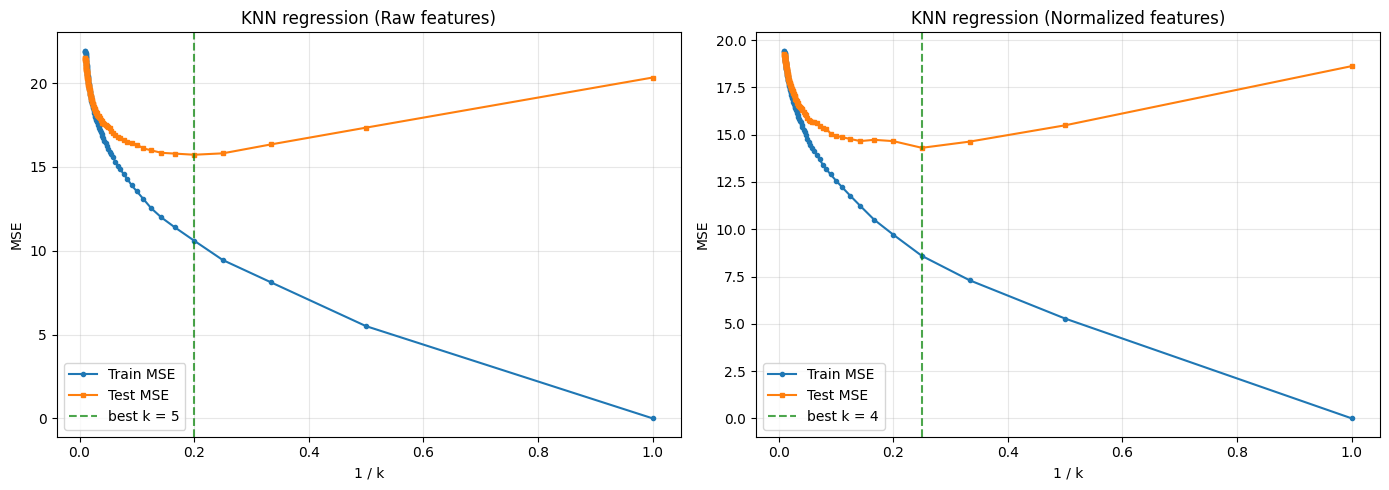

In [27]:
# train and test error vs 1/k, one panel per feature scaling
inv_k = [1 / k for k in ks]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, label in zip(ax, ["Raw", "Normalized"]):
    tr_mse, te_mse, best_k = results[label]
    a.plot(inv_k, tr_mse, "o-", ms=3, label="Train MSE")
    a.plot(inv_k, te_mse, "s-", ms=3, label="Test MSE")
    a.axvline(1 / best_k, color="green", ls="--", alpha=0.7, label=f"best k = {best_k}")
    a.set_xlabel("1 / k"); a.set_ylabel("MSE"); a.set_title(f"KNN regression ({label} features)")
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Results.** Normalization is important: the best fit occurs for k = 4 and the test MSE is around 14.3 for normalized features, while for raw features it is k = 5 and the test MSE is around 15.7. KNN with raw data performs worse and this is due to the fact that Euclidean distance is dominated by AP (which has values around 1013 and above) and by V thus overpowering other variables like AT and RH. Normalization ensures that all predictors are on the same scale and we can observe the curves for both models showing the train error near zero at k = 1 (1/k = 1) and gradually increasing with k while test error is U-shaped in 1/k for both curves thus confirming bias-variance tradeoff concept.

## 1(j) KNN vs. best linear model

**Comparison.** The best linear model is Model 2 from part (h), with test MSE ≈ 18.7. Normalized
KNN (k = 4) reaches test MSE ≈ 14.3, so **KNN clearly outperforms the best linear regression here.**

**Analysis.** KNN is the best technique because it is non-parametric and well-suited to fitting local, nonlinear patterns in data so that we do not need to worry about the types of polynomials and interactions we may or may not have to use. The results from the regressions in (f) and (g) have already demonstrated real curvature and interactions; even Model 2 only reflects what has been added explicitly while KNN captures whatever local shape exists. The trade-offs: KNN does not produce interpretable coefficients, must store and search the entire training set at the time of prediction, is sensitive to feature scaling (as we saw above), and suffers in high-dimensional spaces (curse of dimensionality). Still, because there are only 4 well-scaled predictors and about 9500 data points in this case, the disadvantages are not that strong compared to the flexibility of KNN.

---
# 2. ISLR 2.4.1
How does a **flexible** method compare to an **inflexible** one for each of the given scenario?

**(a)  Large sample size n and small number of predictors p: flexible is better.** With large amounts of data and few predictor variables, a flexible method is useful as it can adequately model complex relationships without overfitting.

**(b) Small n and large number of predictors p: flexible is worse.** When there are small amounts of data and many more predictor variables, flexible methods will be ineffective because of many degrees of freedom which could lead to overfitting.

**(c) Highly non-linear relationship: flexible is better.** In the case of non-linear true connection, a rigid method will fail as it cannot estimate well.

**(d) High error variance: flexible is worse.** When noise variance is high, flexible methods will fit the noise and lead to overfitting.

# 3. ISLR 2.4.7
Training data with three predictors and a qualitative response; test point at X₁ = X₂ = X₃ = 0.

| Obs | X₁ | X₂ | X₃ | Y | Distance to (0,0,0) |
|----|----|----|----|-------|------|
| 1 | 0 | 3 | 0 | Red | 3.00 |
| 2 | 2 | 0 | 0 | Red | 2.00 |
| 3 | 0 | 1 | 3 | Red | 3.16 |
| 4 | 0 | 1 | 2 | Green | 2.24 |
| 5 | −1| 0 | 1 | Green | 1.41 |
| 6 | 1 | 1 | 1 | Red | 1.73 |


In [ ]:
# (a) Computing the Euclidean distance from every training observation to the test point (0,0,0)
obs = {1:(0,3,0,"Red"), 2:(2,0,0,"Red"), 3:(0,1,3,"Red"),
       4:(0,1,2,"Green"), 5:(-1,0,1,"Green"), 6:(1,1,1,"Red")}
dists = {i: (round(float(np.sqrt(x1**2 + x2**2 + x3**2)), 3), y)
         for i,(x1,x2,x3,y) in obs.items()}
for i,(d,y) in sorted(dists.items(), key=lambda kv: kv[1][0]):
    print(f"Obs {i}: distance = {d:5.3f}, Y = {y}")

Obs 5: distance = 1.414, Y = Green
Obs 6: distance = 1.732, Y = Red
Obs 2: distance = 2.000, Y = Red
Obs 4: distance = 2.236, Y = Green
Obs 1: distance = 3.000, Y = Red
Obs 3: distance = 3.162, Y = Red


**(a)** Distances (see output): Obs5 = 1.41, Obs6 = 1.73, Obs2 = 2.00, Obs4 = 2.24, Obs1 = 3.00,
Obs3 = 3.16.

**(b) K = 1 → result: Green.** The nearest neighbor is Obs5 with a distance of 1.41 and a label of Green.  

**(c) K = 3 → result: Red.** The three nearest observations are Obs5 (Green), Obs6 (Red), and Obs2 (Red). The majority is 2 Red and 1 Green; thus, the answer is Red.  

**(d) Small K.** A very non-linear border of the Bayes classifier requires the use of a **small** K. A small K allows KNN to be sensitive to local structure in the data and provides a flexible, local decision boundary.
